In [1]:
import os
import sys

os.chdir("/Users/karima/Ironhack-challenges/fake-news-nlp-classification")
sys.path.append(os.getcwd())

print(os.getcwd())

/Users/karima/Ironhack-challenges/fake-news-nlp-classification


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from src.data_loader import load_data, prepare_features_and_labels, split_data
from src.preprocessing import preprocess_data
from src.feature_extraction import create_bow_features
from src.evaluator import evaluate_model, save_confusion_matrix, save_metrics_plot
from src.experiment_tracker import save_experiment_result
from src.model_manager import save_model, save_vectorizer
from src.config import MODELS_DIR

In [3]:
# Class constants
MODEL_ID = "exp_03"
MODEL_NAME = "Random Forest + Bag of Words"
FEATURES = "Bag of Words"
PREPROCESSING = "Lowercase + HTML removal + stopword removal + lemmatization"
ALGORITHM = "Random Forest"
NOTES = "Random Forest model using Bag of Words features."
MODEL_PATH = MODELS_DIR / "bow_random_forest.pkl"

In [4]:
# Load the dataset
data = load_data()

In [5]:
# Extract features X and labels y
X, y = prepare_features_and_labels(data)

In [6]:
# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = split_data(X, y)

In [7]:
# data cleaning, tokenizationa and lemmatization
X_train_clean = preprocess_data(X_train)
X_test_clean = preprocess_data(X_test)

In [8]:
# # 5. Create Bag of Words features
X_train_bow, X_test_bow, bow_vectorizer = create_bow_features(
    X_train_clean,
    X_test_clean
)

In [9]:
# Train the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_bow, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [10]:
# evaluate the model
metrics, predictions = evaluate_model(
    model,
    X_test_bow,
    y_test
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3989
           1       0.99      0.99      0.99      4000

    accuracy                           0.99      7989
   macro avg       0.99      0.99      0.99      7989
weighted avg       0.99      0.99      0.99      7989



In [11]:
# Save the model and the vectorizer
model_path = save_model(
    model,
    "bow_random_forest.pkl"
)

vectorizer_path = save_vectorizer(
    bow_vectorizer,
    "bow_random_forest_vectorizer.pkl"
)

Model saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/bow_random_forest.pkl
Vectorizer saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/bow_random_forest_vectorizer.pkl


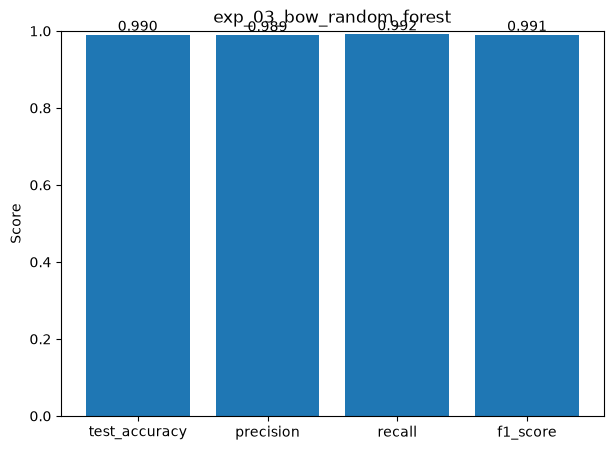

In [12]:
# Save and show metrics plot
metrics_plot_path = save_metrics_plot(
    metrics,
    "exp_03_bow_random_forest"
)

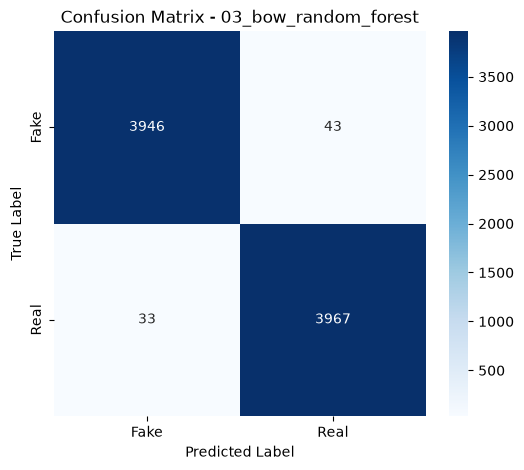

In [13]:
# Save and show confusion matrix
confusion_matrix_path = save_confusion_matrix(
    y_test,
    predictions,
    "03_bow_random_forest"
)

In [14]:
# Train accuracy
train_prediction = model.predict(X_train_bow)

train_accuracy = accuracy_score(
    y_train,
    train_prediction
)

In [15]:
# Save experiment result
experiment = {
 "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "features": FEATURES,
    "preprocessing": PREPROCESSING,
    "algorithm": ALGORITHM,
    "train_accuracy": train_accuracy,
    "test_accuracy": metrics["test_accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "notes": NOTES,
    "model_path": model_path,
}

tracking = save_experiment_result(**experiment)

tracking.tail()

,model_id,model_name,features,preprocessing,algorithm,train_accuracy,test_accuracy,precision,recall,f1_score,notes,model_path
0,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
1,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
2,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
3,exp_02,Naive Bayes + Bag of Words,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Multinomial Naive Bayes,0.959785,0.948429,0.949399,0.94750,0.948448,Naive Bayes model using Bag of Words features.,/Users/karima/Ironhack-challenges/fake-news-nl...
4,exp_03,Random Forest + Bag of Words,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.990487,0.989277,0.99175,0.990512,Random Forest model using Bag of Words features.,/Users/karima/Ironhack-challenges/fake-news-nl...
